# Week 01 - Exploratory Data Analysis & Data Preparation

**DMML - Data Mining & Machine Learning**  
**Due:** End of Week 02  
**Estimated time:** 2-3 hours

This notebook is self-contained. You will use the Titanic dataset to practise the first reusable habits of machine learning: auditing data, checking missing values, making simple plots, cleaning deliberately, and adding interpretable features.


## What You Are Building

This week has five required functions:

1. `audit_dataframe(df)` - reusable dataframe audit.
2. `plot_missingness(df)` - reusable missing-value plot.
3. `plot_group_rates(df, target, groupby_cols)` - reusable target-rate plot.
4. `clean_titanic(df)` - Titanic-specific cleaning decisions.
5. `add_titanic_features(df)` - Titanic-specific feature engineering.

The first three are general EDA helpers. You may reuse them later in the course. The last two are dataset-specific.

The self-checks are visible on purpose. They define the contract your function should satisfy. Passing them is not a guarantee of full marks, but failing them means your implementation is not ready.

Each task ends with a **Tools for this task** list naming the library functions it needs, and what each one gives you. Working out the order to put them in is the exercise. The full reference lives on the [Library Reference page](https://hugoiscracked.github.io/dmml-public/libraries.html).


In [1]:
# Imports - keep this cell stable
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
AGE_BINS = [0, 12, 18, 35, 60, 100]
AGE_LABELS = ["Child", "Teen", "Young Adult", "Adult", "Senior"]


In [2]:
# Load the data
raw_df = sns.load_dataset("titanic")
print(f"Shape: {raw_df.shape}")
raw_df.head()


Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Warm-Up: First Look

Before writing functions, inspect the data directly. 


In [3]:
print("Data types:")
display(raw_df.dtypes)

print("Basic summary:")
display(raw_df.describe(include="all"))


Data types:


survived          int64
pclass            int64
sex                 str
age             float64
sibsp             int64
parch             int64
fare            float64
embarked            str
class          category
who                 str
adult_male         bool
deck           category
embark_town         str
alive               str
alone              bool
dtype: object

Basic summary:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Task 1 - Reusable Dataframe Audit

Implement `audit_dataframe(df)`.

Return one row per column with exactly these columns:

- `column`
- `dtype`
- `n_missing`
- `pct_missing`
- `n_unique`
- `sample_values`

Sort by `pct_missing` descending, then by `column` ascending. Do not print inside the function.

Design hint: `sample_values` can be a short list of up to three non-missing values.

**Tools for this task** — reference: [pandas](https://hugoiscracked.github.io/dmml-public/libraries.html#pandas)

- `df.columns / df.dtypes` — iterate the columns and read the type of each
- `s.isna().sum()` — how many values are missing in one column
- `s.nunique()` — how many distinct values it has
- `s.dropna()` — drop the missing values before taking example values
- `s.head(n) / s.tolist()` — a few values, as a plain Python list
- `pd.DataFrame(rows)` — build the result from a list of dicts
- `df.sort_values(by=[...], ascending=[...])` — sort by two keys with different directions


In [ ]:
def audit_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    """Return a column-level audit table for any dataframe."""
    # YOUR CODE HERE
    raise NotImplementedError


In [ ]:
# Self-check: Task 1

audit = audit_dataframe(raw_df)
expected_cols = ["column", "dtype", "n_missing", "pct_missing", "n_unique", "sample_values"]

assert isinstance(audit, pd.DataFrame), "audit_dataframe must return a DataFrame"
assert list(audit.columns) == expected_cols, f"Expected columns {expected_cols}"
assert len(audit) == raw_df.shape[1], "There should be one audit row per input column"
assert audit.loc[audit["column"] == "deck", "pct_missing"].iloc[0] > 70, "deck should be mostly missing"
assert audit["pct_missing"].is_monotonic_decreasing, "Sort by pct_missing descending"

# Toy dataframe: catches Titanic-only hard-coding.
tiny = pd.DataFrame({"a": [1, None, 3], "b": ["x", "x", None]})
tiny_audit = audit_dataframe(tiny)
assert set(tiny_audit["column"]) == {"a", "b"}
assert tiny_audit["n_missing"].sum() == 2

print("Task 1 passed")
audit


## Task 2 - Missingness Plot

Implement `plot_missingness(df)`.

It should return `(fig, ax)` and show where values are missing. Use any clear color scheme, but the title and axis labels should make the plot understandable.

**Tools for this task** — reference: [pandas](https://hugoiscracked.github.io/dmml-public/libraries.html#pandas) · [seaborn](https://hugoiscracked.github.io/dmml-public/libraries.html#seaborn) · [Matplotlib](https://hugoiscracked.github.io/dmml-public/libraries.html#matplotlib)

- `df.isna()` — a boolean frame: True wherever a value is missing
- `plt.subplots(figsize=(w, h))` — create the figure and axes
- `sns.heatmap(data, cbar=False)` — draw a boolean matrix as colour
- `ax.set_title / .set_xlabel / .set_ylabel` — make the plot readable on its own


In [ ]:
def plot_missingness(df: pd.DataFrame):
    """Plot a missing-value heatmap and return (fig, ax)."""
    # YOUR CODE HERE
    raise NotImplementedError


In [ ]:
# Self-check: Task 2
fig, ax = plot_missingness(raw_df)
assert fig is not None and ax is not None, "Return (fig, ax)"
assert ax.get_title(), "Add a descriptive title"
plt.show()
print("Task 2 passed")


## Guided EDA: Distributions and Relationships

The next cells are analysis cells rather than required functions. Run them, inspect the outputs, and use them in your reflection.


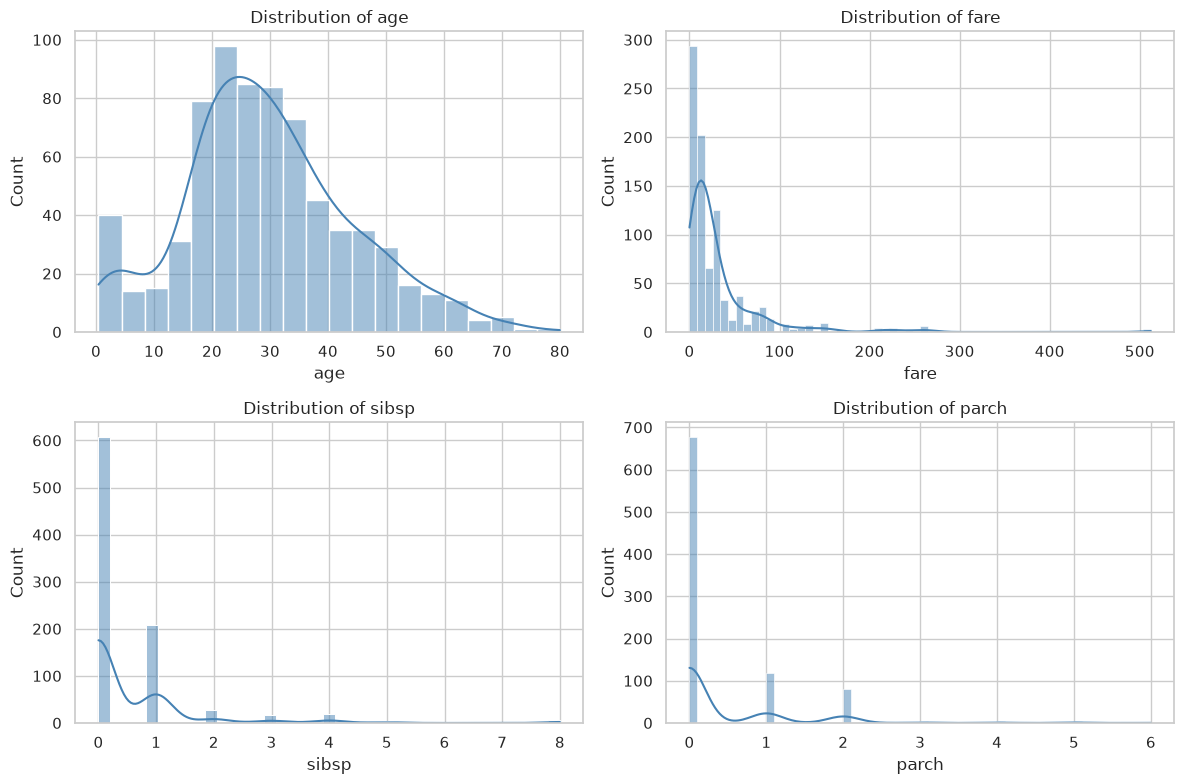

,column,skewness
1,fare,4.787317
2,sibsp,3.695352
3,parch,2.749117
0,age,0.389108


In [4]:
# Numeric distributions
numeric_cols = ["age", "fare", "sibsp", "parch"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for ax, col in zip(axes, numeric_cols):
    values = raw_df[col].dropna()
    sns.histplot(values, kde=True, ax=ax, color="steelblue")
    ax.set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

skew_table = (
    raw_df[numeric_cols]
    .skew(numeric_only=True)
    .rename("skewness")
    .reset_index()
    .rename(columns={"index": "column"})
    .sort_values("skewness", ascending=False)
)
skew_table


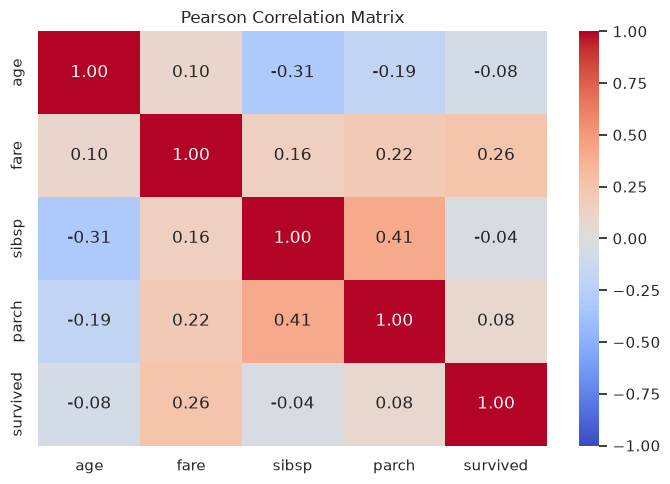

In [5]:
# Correlation heatmap for numeric columns plus target
corr_cols = numeric_cols + ["survived"]
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(raw_df[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("Pearson Correlation Matrix")
plt.tight_layout()
plt.show()


## Task 3 - Grouped Target Rates

Implement `plot_group_rates(df, target, groupby_cols)`.

For each grouping column, compute the mean target value and the group size. Return three objects:

```python
fig, axes, summary
```

`summary` must be a tidy dataframe with columns:

- `feature`
- `group`
- `rate`
- `count`

Each plot should show one bar per group and annotate the group count.

**Tools for this task** — reference: [pandas](https://hugoiscracked.github.io/dmml-public/libraries.html#pandas) · [Matplotlib](https://hugoiscracked.github.io/dmml-public/libraries.html#matplotlib)

- `df.groupby(col)[target].agg(['mean', 'size'])` — the rate and the group size in one call
- `df.reset_index()` — turn the group index back into a normal column
- `pd.concat(frames, ignore_index=True)` — stack the per-feature summaries into one tidy table
- `plt.subplots(1, n, figsize=...)` — one axes per grouping column
- `axes.ravel()` — iterate a grid of axes as a flat list
- `ax.bar(x, height)` — one bar per group
- `ax.set_xticks(pos) / ax.set_xticklabels(names)` — put the group names, and their counts, on the x axis


In [ ]:
def plot_group_rates(df: pd.DataFrame, target: str, groupby_cols: list[str]):
    """Plot target rate by group and return (fig, axes, summary)."""
    # YOUR CODE HERE
    raise NotImplementedError


In [ ]:
# Self-check: Task 3
fig, axes, rate_summary = plot_group_rates(raw_df, target="survived", groupby_cols=["sex", "pclass", "embarked"])

assert fig is not None and axes is not None, "Return fig and axes"
assert isinstance(rate_summary, pd.DataFrame), "summary must be a DataFrame"
assert {"feature", "group", "rate", "count"}.issubset(rate_summary.columns)
assert rate_summary["rate"].between(0, 1).all(), "Rates should be proportions between 0 and 1"
assert rate_summary["count"].gt(0).all(), "Each displayed group should have a positive count"

plt.show()
print("Task 3 passed")
rate_summary


## Task 4 - Titanic Cleaning Pipeline

Implement `clean_titanic(df)`.

Rules:

1. Work on a copy; do not mutate the input dataframe.
2. Fill missing `age` using grouped median by `(pclass, sex)`.
3. If a grouped median is unavailable, fall back to the global median age.
4. Fill missing `embarked` and `embark_town` with their modes.
5. Drop `deck`, because it is mostly missing.

This function is dataset-specific. It is acceptable that it assumes Titanic column names.

**Tools for this task** — reference: [pandas](https://hugoiscracked.github.io/dmml-public/libraries.html#pandas)

- `df.copy()` — work on a copy so the caller's frame is untouched
- `df.groupby([...])[col].transform('median')` — the group median, aligned back to every original row
- `s.fillna(value)` — replace missing values; the value can be a scalar or an aligned Series
- `s.median()` — the global fallback when a group has no median
- `s.mode()` — the most frequent value — returns a Series, so take element `[0]`
- `df.drop(columns=[...])` — remove a column entirely


In [ ]:
def clean_titanic(df: pd.DataFrame) -> pd.DataFrame:
    """Return a cleaned copy of the Titanic dataframe."""
    # YOUR CODE HERE
    raise NotImplementedError


In [ ]:
# Self-check: Task 4
clean_df = clean_titanic(raw_df)

assert clean_df is not raw_df, "Return a copy; do not mutate the input"
assert raw_df["age"].isna().sum() > 0, "The raw dataframe should remain unchanged"
assert clean_df["age"].isna().sum() == 0, "All ages should be imputed"
assert clean_df["embarked"].isna().sum() == 0, "embarked should be imputed"
assert clean_df["embark_town"].isna().sum() == 0, "embark_town should be imputed"
assert "deck" not in clean_df.columns, "deck should be dropped"

# Toy dataframe: catches global-median-only imputation.
tiny = pd.DataFrame({
    "pclass": [1, 1, 3, 3],
    "sex": ["female", "female", "male", "male"],
    "age": [40.0, np.nan, 18.0, np.nan],
    "embarked": ["S", np.nan, "C", "C"],
    "embark_town": ["Southampton", np.nan, "Cherbourg", "Cherbourg"],
    "deck": [np.nan, np.nan, np.nan, np.nan],
})
tiny_clean = clean_titanic(tiny)
assert tiny_clean.loc[1, "age"] == 40.0, "Use grouped age median when available"
assert tiny_clean.loc[3, "age"] == 18.0, "Use grouped age median when available"

print("Task 4 passed")
clean_df.head()


## Task 5 - Titanic Feature Engineering

Implement `add_titanic_features(df)`.

Add:

- `family_size = sibsp + parch + 1`
- `is_alone = 1` when `family_size == 1`, otherwise `0`
- `age_group` using `AGE_BINS` and `AGE_LABELS`

Return a copy with the new columns added.

**Tools for this task** — reference: [pandas](https://hugoiscracked.github.io/dmml-public/libraries.html#pandas)

- `df.copy()` — again, do not mutate the input
- `s.astype(int)` — turn a boolean condition into a 0/1 column
- `pd.cut(s, bins=AGE_BINS, labels=AGE_LABELS)` — bin a numeric column into labelled categories


In [ ]:
def add_titanic_features(df: pd.DataFrame) -> pd.DataFrame:
    """Return a copy with Titanic-specific engineered features."""
    # YOUR CODE HERE
    raise NotImplementedError


In [ ]:
# Self-check: Task 5
feature_df = add_titanic_features(clean_df)

for col in ["family_size", "is_alone", "age_group"]:
    assert col in feature_df.columns, f"Missing engineered column: {col}"

assert feature_df is not clean_df, "Return a copy; do not mutate the input"
assert feature_df["family_size"].equals(feature_df["sibsp"] + feature_df["parch"] + 1)
assert set(feature_df["is_alone"].unique()).issubset({0, 1})
assert feature_df.loc[feature_df["family_size"] == 1, "is_alone"].eq(1).all()
assert feature_df["age_group"].isna().sum() == 0

print("Task 5 passed")
feature_df[["family_size", "is_alone", "age_group"]].head()


## Final Analysis Outputs

Run these cells after all functions pass. These are the outputs your submitted notebook should contain.


In [ ]:
# 1. Final audit table
audit_dataframe(raw_df)


In [ ]:
# 2. Missingness heatmap
plot_missingness(raw_df)
plt.show()


In [ ]:
# 3. Outcome rates for original variables
plot_group_rates(raw_df, "survived", ["sex", "pclass", "embarked"])
plt.show()


In [ ]:
# 4. Outcome rates for engineered variables
plot_group_rates(feature_df, "survived", ["age_group", "is_alone"])
plt.show()


## Challenge Tracks Optional

Choose zero, one, or more.

### Track A - Extension
Apply `audit_dataframe`, `plot_missingness`, and `plot_group_rates` to another seaborn dataset such as `penguins` or `tips`. Write two sentences about what changed.

### Track B - Robustness
Improve one required function so it handles an awkward case gracefully, such as an empty dataframe, an all-missing column, or missing group labels.

### Track C - Product
Create a compact Markdown or HTML report containing the audit table, top missing columns, and two saved figures.


In [ ]:
# Optional challenge workspace
# Your code here
